In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

From Kaggle I have downloaded the dataset named student_dropout_prediction file.


The objective of my project "Education" is related to prediction of whether a student is likely to drop out based on academics, time spent per day, CGPA, study hours and other factors. Early idetification of such students will enable educational institution to take various proactive measures to ensure proper counselling, financial support and academic intervention.

In [2]:
from google.colab import files
uploaded = files.upload()

Saving Studentdataset.zip to Studentdataset.zip


In [3]:
import zipfile
import os

zip_path = "Studentdataset.zip"
extract_path = "data"

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
  zip_ref.extractall(extract_path)

print("Files extracted:", os.listdir(extract_path))

Files extracted: ['student_dropout_dataset_v3.csv']


Now after importing the dataset I need to import the libraries which are required for the problem

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, RocCurveDisplay
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

import warnings
warnings.filterwarnings("ignore")

Now I need to load the dataset to check the number of rows and columns, data types, names of the column and missing values

In [5]:
df= pd.read_csv("data/student_dropout_dataset_v3.csv")
df.head()

,Student_ID,Age,Gender,Family_Income,Internet_Access,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Part_Time_Job,Scholarship,Stress_Index,GPA,Semester_GPA,CGPA,Semester,Department,Parental_Education,Dropout
0,1,22.1,Male,25000.0,Yes,3.36,86.1,2,20.4,Yes,No,5.5,0.96,0.90,0.90,Year 1,Arts,High School,0
1,2,20.7,Male,25000.0,Yes,4.30,68.0,2,44.0,No,No,6.8,1.28,1.20,1.19,Year 3,Engineering,Bachelor,1
2,3,22.4,Male,40183.0,Yes,4.40,70.9,0,48.9,Yes,No,5.5,1.68,1.32,1.32,Year 1,Arts,Master,0
3,4,24.4,Male,NaN,Yes,NaN,82.2,2,38.6,No,No,NaN,1.78,1.77,1.77,Year 1,CS,High School,1
4,5,20.5,Female,25319.0,Yes,4.19,75.7,1,23.0,No,No,7.0,1.48,0.91,0.87,Year 4,Business,Bachelor,0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Student_ID             10000 non-null  int64  
 1   Age                    10000 non-null  float64
 2   Gender                 10000 non-null  object 
 3   Family_Income          9500 non-null   float64
 4   Internet_Access        10000 non-null  object 
 5   Study_Hours_per_Day    9500 non-null   float64
 6   Attendance_Rate        10000 non-null  float64
 7   Assignment_Delay_Days  10000 non-null  int64  
 8   Travel_Time_Minutes    10000 non-null  float64
 9   Part_Time_Job          10000 non-null  object 
 10  Scholarship            10000 non-null  object 
 11  Stress_Index           9500 non-null   float64
 12  GPA                    10000 non-null  float64
 13  Semester_GPA           10000 non-null  float64
 14  CGPA                   10000 non-null  float64
 15  Sem

This is a binary classification problem, and the goal is to classify students in two categories: "0"- not likely to dropout and "1" - likely to drop out.

In [7]:
df.describe()

,Student_ID,Age,Family_Income,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Stress_Index,GPA,Semester_GPA,CGPA,Dropout
count,10000.00000,10000.00000,9500.000000,9500.000000,10000.00000,10000.000000,10000.00000,9500.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,21.02606,38377.247474,4.014592,81.73683,1.799700,30.17926,5.507147,2.308440,2.300057,2.298761,0.23540
std,2886.89568,2.13981,20496.232179,1.295450,8.22093,1.344307,11.91887,1.765951,1.061717,1.074407,1.072555,0.42427
min,1.00000,17.00000,25000.000000,0.500000,38.20000,0.000000,5.00000,1.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,19.50000,25000.000000,3.160000,76.40000,1.000000,21.90000,4.300000,1.550000,1.520000,1.520000,0.00000
50%,5000.50000,21.00000,29740.500000,4.000000,81.80000,2.000000,30.20000,5.500000,2.350000,2.350000,2.350000,0.00000
75%,7500.25000,22.50000,44520.000000,4.870000,87.30000,3.000000,38.40000,6.700000,3.120000,3.150000,3.150000,0.00000
max,10000.00000,29.60000,316601.000000,8.980000,100.00000,8.000000,74.90000,10.000000,4.000000,4.000000,4.000000,1.00000


Dataset was obtained from kaggle. https://www.kaggle.com/datasets/meharshanali/student-dropout-prediction-dataset .This gives summary statistics for all 19 columns. It provides us with mean, count, std, min, max, and quartiles.

In [8]:
df["Dropout"].value_counts(normalize=True)*100

,proportion
Dropout,
0,76.46
1,23.54


In [9]:
df.isnull().sum().sort_values(ascending = False)

,0
Parental_Education,511
Family_Income,500
Stress_Index,500
Study_Hours_per_Day,500
Gender,0
Student_ID,0
Age,0
Assignment_Delay_Days,0
Travel_Time_Minutes,0
Internet_Access,0


In [10]:
df.duplicated().sum()

np.int64(0)

So no duplicate values, missing values has been sorted and now we can remove unnecessary column such as studentID becasuse it has no role in predicting student dropout risk. It is just an identifier, not a real feature.

In [11]:
df = df.drop (columns= ["Student_ID"])

In [12]:
X = df.drop("Dropout", axis = 1)
y = df["Dropout"]

Identifying numeric and categorical column because preprocessing is different. Numeric which are stored as decimal and integers (int64 & float64). whereas, categorical are stored as object in pandas categorised as text and labels.

In [13]:
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

Numeric features: ['Age', 'Family_Income', 'Study_Hours_per_Day', 'Attendance_Rate', 'Assignment_Delay_Days', 'Travel_Time_Minutes', 'Stress_Index', 'GPA', 'Semester_GPA', 'CGPA']
Categorical features: ['Gender', 'Internet_Access', 'Part_Time_Job', 'Scholarship', 'Semester', 'Department', 'Parental_Education']


Now the next step is Exploratory Data Analysis which shows how amny students dropped out versus remanined enrolled.

In [14]:
X = df.drop("Dropout", axis=1)
y = df["Dropout"]

In [15]:

corr_matrix = df.corr(numeric_only=True).abs()

upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

to_drop = [column for column in upper.columns if any(upper[column] > 0.9)]

print("Highly correlated features to drop:", to_drop)

Highly correlated features to drop: ['Semester_GPA', 'CGPA']


In [16]:
df = df.drop(columns=to_drop)

X = df.drop("Dropout", axis=1)
y = df["Dropout"]

In [19]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Select numeric data
numeric_data = df.select_dtypes(include=["int64", "float64"]).drop(columns=["Dropout"])

# Fill missing values
numeric_data = numeric_data.fillna(numeric_data.median())

# Scale data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(numeric_data)

# Now this will work
import numpy as np
print("Missing values after scaling:", np.isnan(scaled_data).sum())

Missing values after scaling: 0


In [20]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Select only numeric columns except target
numeric_data = df.select_dtypes(include=["int64", "float64"]).drop(columns=["Dropout"])

# Check missing values before filling
print("Missing values before imputation:", numeric_data.isnull().sum().sum())

# Fill missing values with median
numeric_data = numeric_data.fillna(numeric_data.median())

# Check again
print("Missing values after imputation:", numeric_data.isnull().sum().sum())

# Scale the data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(numeric_data)

# Apply PCA
pca = PCA(n_components=0.95)
pca_data = pca.fit_transform(scaled_data)

print("Original features:", scaled_data.shape[1])
print("Reduced features:", pca_data.shape[1])

Missing values before imputation: 1500
Missing values after imputation: 0
Original features: 8
Reduced features: 8


In [21]:
print(numeric_data.columns.tolist())

['Age', 'Family_Income', 'Study_Hours_per_Day', 'Attendance_Rate', 'Assignment_Delay_Days', 'Travel_Time_Minutes', 'Stress_Index', 'GPA']


In [22]:
numeric_features = df.select_dtypes(include=["int64", "float64"]).columns.tolist()

# remove target manually
numeric_features.remove("Dropout")

print(numeric_features)

['Age', 'Family_Income', 'Study_Hours_per_Day', 'Attendance_Rate', 'Assignment_Delay_Days', 'Travel_Time_Minutes', 'Stress_Index', 'GPA']


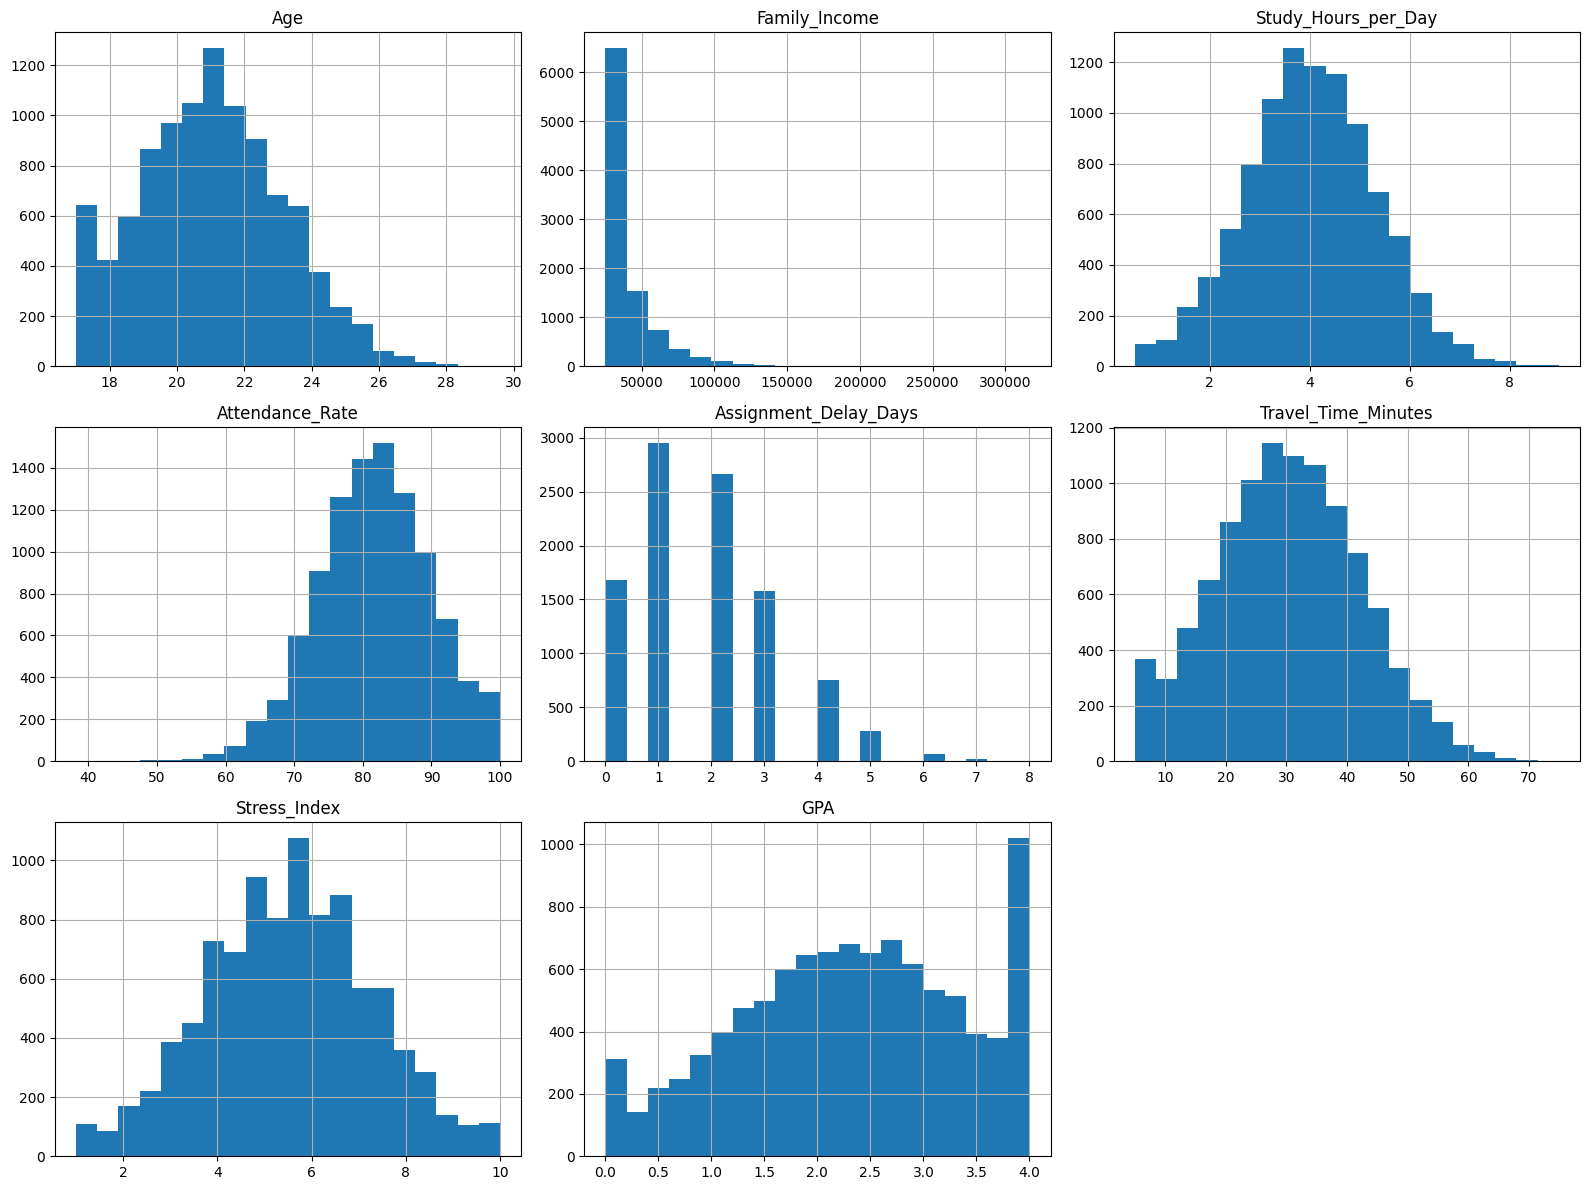

In [23]:
df[numeric_features].hist(figsize=(16, 12), bins=20)
plt.tight_layout()
plt.show()

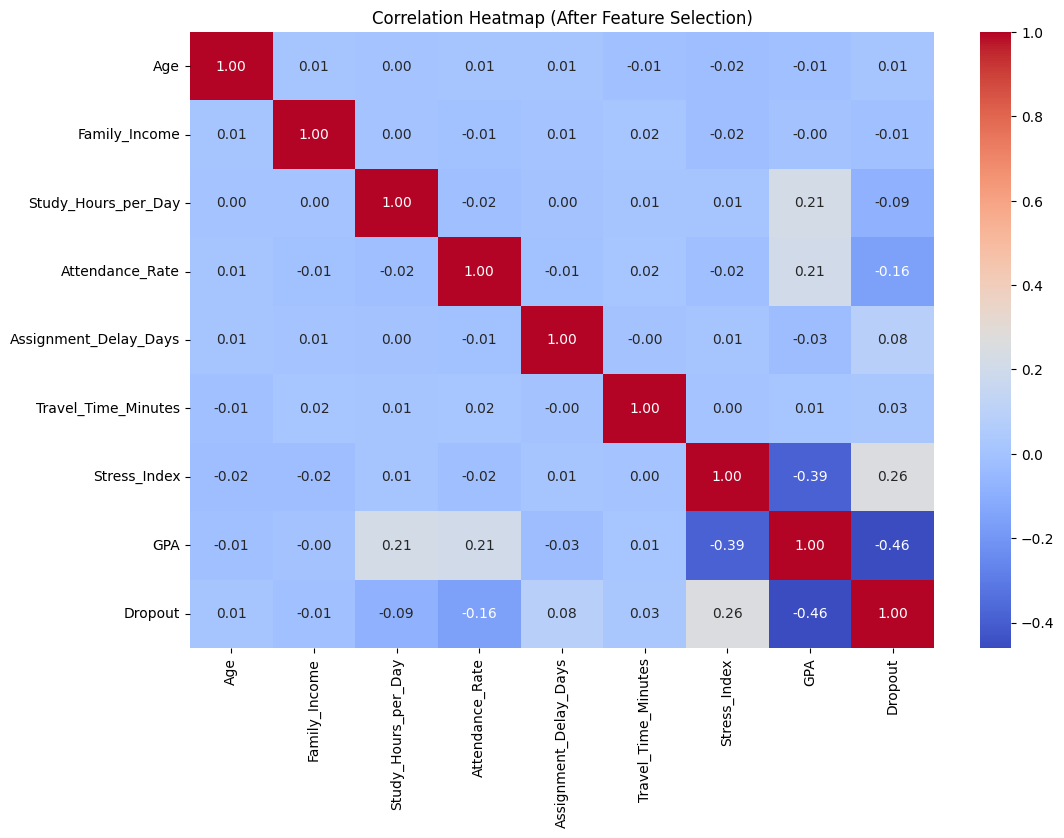

In [24]:
numeric_features = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
numeric_features.remove("Dropout")
plt.figure(figsize=(12, 8))
sns.heatmap(df[numeric_features + ["Dropout"]].corr(),
            annot=True,
            cmap="coolwarm",
            fmt=".2f")

plt.title("Correlation Heatmap (After Feature Selection)")
plt.show()

This correlation heatmap shows numeric features are positively or negatively related to dropout. In this +1 shows strong positive relationship; -1 shows negative reationship and 0 shows no relationship. Few observations which needs to be noted are -

1. GPA, Semester_GPA, CGPA are almost identical or related in the sense if one incrases, others also increase. so the reduntant features are removed.

2. Dropout is negatively correlated with academic performance means students who have higher GPA have lower dropout chance & lower GPA have a higher dropout risk.

3. Stress Index positively correlated with Dropout. It means higher stress have more dropout probability. Stress index shows a positive correlation with dropout, suggesting students experiencing higher stress levels are more likely to drop out.

4. Attendance has weak negative correlation with dropout and is around 0.16. It suggests students with lower attendance are slghtly more likely to drop out.

5. study hours have weak effect suggesting limited impact.

6. Age, Family Income and Travel_Time shows no relation with dropout indicating limited or no influence.

7. Stress index is negatively correlated with GPA (having -0.39), indicating that higher stress levels are associated with poorer academic performance.

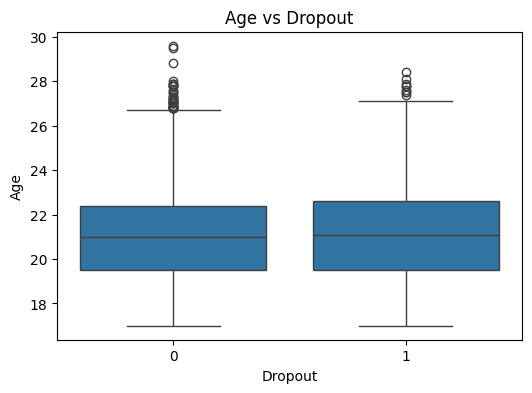

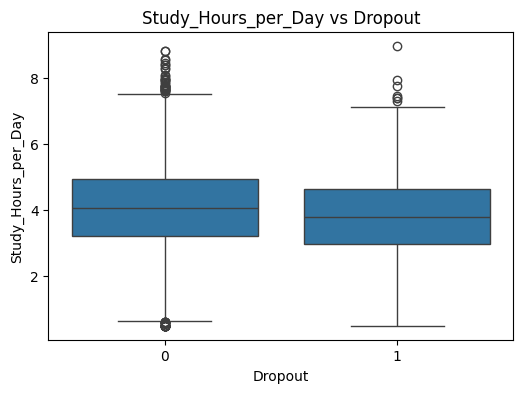

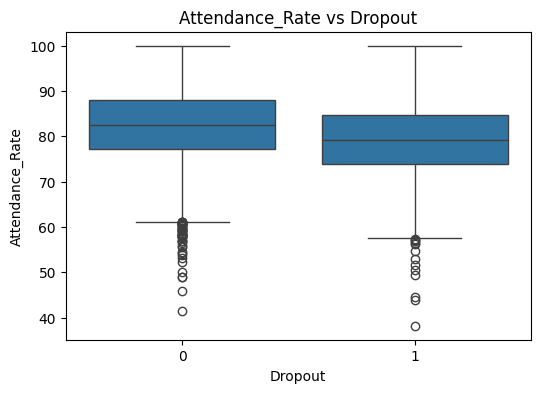

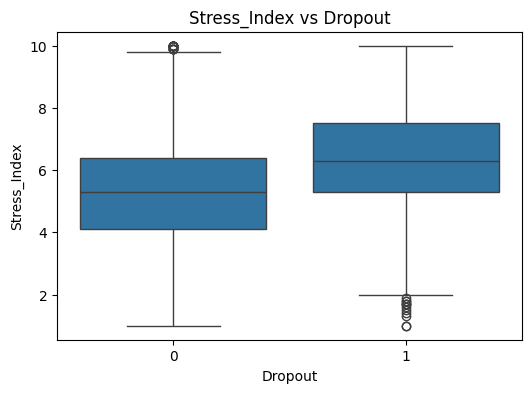

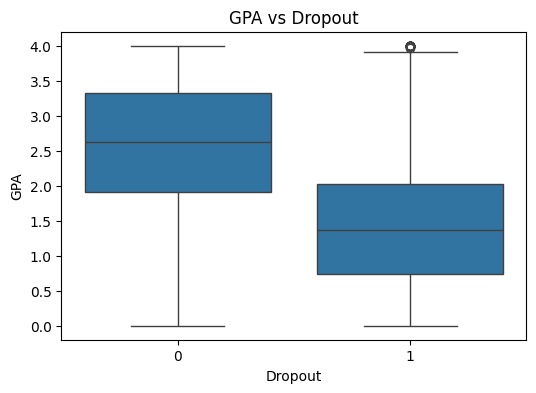

In [25]:
for col in ["Age", "Study_Hours_per_Day", "Attendance_Rate", "Stress_Index", "GPA"]:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x="Dropout", y=col, data=df)
    plt.title(f"{col} vs Dropout")
    plt.show()

In [26]:
from sklearn.model_selection import train_test_split

X = df.drop("Dropout", axis=1)
y = df["Dropout"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape, X_test.shape)

(8000, 15) (2000, 15)


The dataset is split ito training and testing sets with 80:20 ratio. Stratified sampling is used to preserve the class distribution of the target variable.

In [27]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

print("Preprocessing pipeline created successfully")

Preprocessing pipeline created successfully


A Preprocessing pipeline is created successfully using ColumnTransformer. Numerical variables were imputed using the median and scale using StandardScalar.

In [28]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

log_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])

log_model.fit(X_train, y_train)

print("Logistic Regression model trained successfully")

Logistic Regression model trained successfully


Logistic Regression was used as the baseline classification model. It is simple, interpretable, and suitable for binary classification tasks such as dropout prediction.

In [29]:
y_pred_log = log_model.predict(X_test)
y_prob_log = log_model.predict_proba(X_test)[:, 1]

print("Predictions completed")

Predictions completed


y_pred_log gives final predicted class: 0 or 1
y_prob_log gives dropout probability between 0 and 1

Example:

0.82 means 82% predicted dropout chance
0.10 means low dropout chance. Predicted class is used for accuracy, precision, recall, F1
predicted probability is used for ROC-AUC.
The trained Logistic Regression model was used to generate class predictions and class probabilities on the test dataset. Predicted labels were used for classification metrics, while predicted probabilities were used to compute ROC-AUC.

In [30]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("Precision:", precision_score(y_test, y_pred_log))
print("Recall:", recall_score(y_test, y_pred_log))
print("F1-score:", f1_score(y_test, y_pred_log))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_log))

Accuracy: 0.8165
Precision: 0.6857142857142857
Recall: 0.40764331210191085
F1-score: 0.511318242343542
ROC-AUC: 0.8205340765025501


So, as it can be seen from the results that accuracy is good around 81% ; precision is 0.68, which is okay; F1 needs to be improved; Roc-AUc is strong but recall is 0.40 which is poor. As recall is important parameter at identifying risk it suggests model faols to identify significant proportion of dropout cases. So, in this case we need to try with diffeent model i.e., Random Forest

In [31]:
from sklearn.ensemble import RandomForestClassifier

rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(n_estimators=200, random_state=42))
])

rf_model.fit(X_train, y_train)

print("Random Forest trained")

Random Forest trained


In [32]:
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

print("Random Forest predictions completed")

Random Forest predictions completed


In [33]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1-score:", f1_score(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))

Accuracy: 0.805
Precision: 0.6613545816733067
Recall: 0.3524416135881104
F1-score: 0.4598337950138504
ROC-AUC: 0.8072321528995681


So, after appliying other model such as Random Forest it can be noted that recall is still low i.e., 0.35 even less than logistic regression model. Instead of changing the model now, we will try threshold tuning to improve recall. Instead of 0.5 default we should try with 0.3 to predict dropout cases. Lowering the threshold increases recall by identifying more dropout cases, which is desirable in this problem.

In [34]:
y_prob_log

array([0.10304772, 0.22556041, 0.08307516, ..., 0.08275976, 0.32205295,
       0.45506436])

In [35]:
threshold = 0.3

y_pred_new = (y_prob_log >= threshold).astype(int)

In [36]:
from sklearn.metrics import recall_score, precision_score, f1_score

print("New Recall:", recall_score(y_test, y_pred_new))
print("New Precision:", precision_score(y_test, y_pred_new))
print("New F1:", f1_score(y_test, y_pred_new))

New Recall: 0.6772823779193206
New Precision: 0.5178571428571429
New F1: 0.5869365225390984


After reducing the threshold it can be seen that recall value goes up to 0.68 which states model detects 68% dropout students. Best model we can say is logistic regression with threshold value of 0.3. Although precision decreased, this trade-off is acceptable because detecting potential dropouts is more critical than minimizing false positives.

Now moving into step 5.. Since my final model is Logistic Regression with threshold tuning, i will use SHAP for explainability.

In [37]:
!pip install shap

In [38]:
import shap
import pandas as pd
import numpy as np

# Get preprocessor and trained logistic model from pipeline
preprocessor_fitted = log_model.named_steps["preprocessor"]
classifier_fitted = log_model.named_steps["model"]

# Transform training and test data
X_train_transformed = preprocessor_fitted.transform(X_train)
X_test_transformed = preprocessor_fitted.transform(X_test)

# Get feature names after preprocessing
num_features = numeric_features
cat_encoder = preprocessor_fitted.named_transformers_["cat"].named_steps["encoder"]
cat_feature_names = cat_encoder.get_feature_names_out(categorical_features)

all_feature_names = list(num_features) + list(cat_feature_names)

# Convert sparse matrix if needed
if hasattr(X_train_transformed, "toarray"):
    X_train_transformed_dense = X_train_transformed.toarray()
    X_test_transformed_dense = X_test_transformed.toarray()
else:
    X_train_transformed_dense = X_train_transformed
    X_test_transformed_dense = X_test_transformed

print("Transformed training shape:", X_train_transformed_dense.shape)
print("Number of feature names:", len(all_feature_names))

Transformed training shape: (8000, 29)
Number of feature names: 29


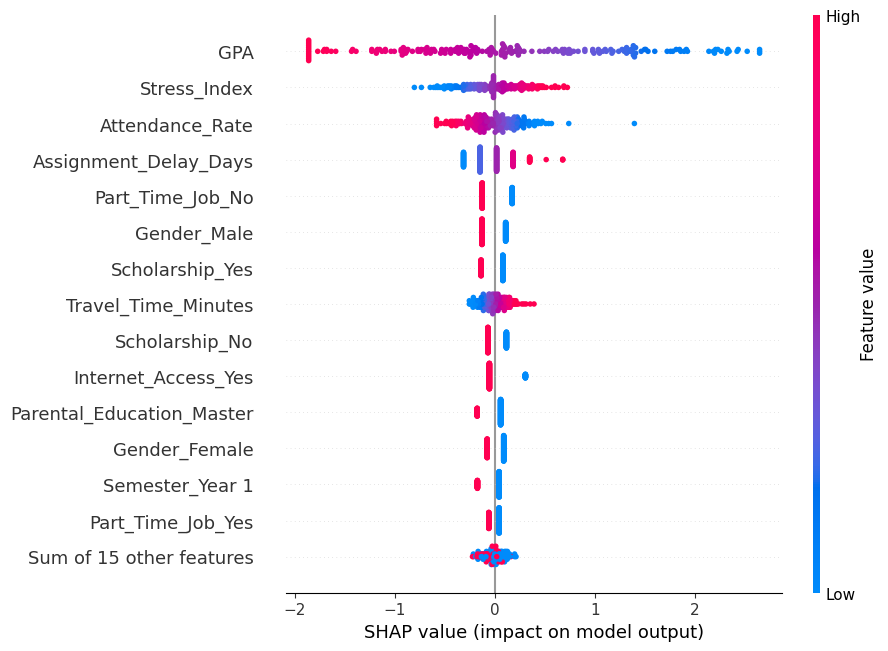

In [39]:
explainer = shap.Explainer(classifier_fitted, X_train_transformed_dense, feature_names=all_feature_names)
shap_values = explainer(X_test_transformed_dense[:200])  # use first 200 samples for speed

shap.plots.beeswarm(shap_values, max_display=15)

According to the SHAP (beeswarm) X-axis indicates dropout risk and Y-axis indicates reduced droput risk .. Red indicates high values whereas, blue shows low values. GPA is most important from the graph bcz it indicates low GPA is equivalent to high dropout risk. Next is Stress index which is considered here as important as it contributes positively to dropout probability. Attendance rate also plays significant role as it is associated with increased dropout risk. The SHAP bar plot confirms these findings by ranking features based on their average contribution to the model output.SHAP analysis aligns with the domain i have chosen, as academic performance and psychological factors are known to be critical determinants of student retention.

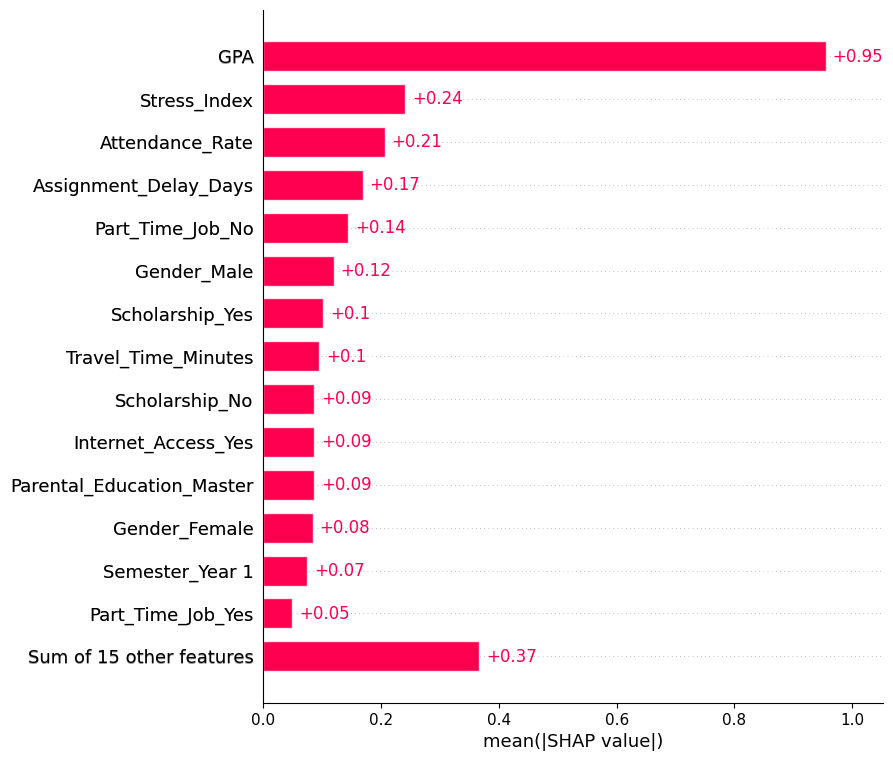

In [40]:
shap.plots.bar(shap_values, max_display=15)

Now We have to do BIAS AUDIT just to check if model behaves differntly for different groups. we are going to check Gender and scholarship bcz even if model gives good accuracy it may be unfair which means it may predict dropout more for females and misses male droputs. This is what bias is.

In [41]:
threshold = 0.3
y_pred_final = (y_prob_log >= threshold).astype(int)

bias_df = X_test.copy()
bias_df["Actual"] = y_test.values
bias_df["Predicted"] = y_pred_final
bias_df["Predicted_Prob"] = y_prob_log

In [42]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

gender_results = []

for group in bias_df["Gender"].dropna().unique():
    subset = bias_df[bias_df["Gender"] == group]

    gender_results.append({
        "Gender": group,
        "Count": len(subset),
        "Actual_Dropout_Rate": subset["Actual"].mean(),
        "Predicted_Dropout_Rate": subset["Predicted"].mean(),
        "Accuracy": accuracy_score(subset["Actual"], subset["Predicted"]),
        "Precision": precision_score(subset["Actual"], subset["Predicted"], zero_division=0),
        "Recall": recall_score(subset["Actual"], subset["Predicted"], zero_division=0),
        "F1": f1_score(subset["Actual"], subset["Predicted"], zero_division=0)
    })

gender_fairness_df = pd.DataFrame(gender_results)
gender_fairness_df

,Gender,Count,Actual_Dropout_Rate,Predicted_Dropout_Rate,Accuracy,Precision,Recall,F1
0,Female,1006,0.234592,0.319085,0.772366,0.510903,0.694915,0.588869
1,Male,994,0.236419,0.296781,0.778672,0.525424,0.659574,0.584906


This results shows there is balance across gender in dropout rates and model does not unfairly targeted any one gender. The fairness evaluation confirms that the model maintains equitable predictive performance across gender groups, making it suitable for deployment in educational decision-support systems.

In [43]:
scholarship_results = []

for group in bias_df["Scholarship"].dropna().unique():
    subset = bias_df[bias_df["Scholarship"] == group]

    scholarship_results.append({
        "Scholarship": group,
        "Count": len(subset),
        "Actual_Dropout_Rate": subset["Actual"].mean(),
        "Predicted_Dropout_Rate": subset["Predicted"].mean(),
        "Accuracy": accuracy_score(subset["Actual"], subset["Predicted"]),
        "Precision": precision_score(subset["Actual"], subset["Predicted"], zero_division=0),
        "Recall": recall_score(subset["Actual"], subset["Predicted"], zero_division=0),
        "F1": f1_score(subset["Actual"], subset["Predicted"], zero_division=0)
    })

scholarship_fairness_df = pd.DataFrame(scholarship_results)
scholarship_fairness_df

,Scholarship,Count,Actual_Dropout_Rate,Predicted_Dropout_Rate,Accuracy,Precision,Recall,F1
0,Yes,736,0.221467,0.269022,0.781250,0.505051,0.613497,0.554017
1,No,1264,0.243671,0.330696,0.772152,0.523923,0.711039,0.603306


Fairness analysis was also conducted across cholarship just to check bias again n its potential. The differencees are consistent with the domain knowledge , as students with any financial support i.e., scholarship may face higher droput risk, suggesting model captures meaningful real-world patterns rathers than exhibiting harmful bias.